In [1]:
# ---------------------------------------------
# Import required libraries
# ---------------------------------------------

# Data handling and numerical operations
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt


In [2]:

import pandas as pd

# GitHub raw URL for the cleaned dataset
url = "https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Final%20Project/Data/Final_Cleaned_Data/Calgary_PM25_Weather_Cleaned_v3.csv"

# Read the dataset directly from GitHub
df = pd.read_csv(url)

# Convert the date column to datetime format
df["date"] = pd.to_datetime(df["date"])

# Preview the first rows
df.head()


,date,PM25,Mean Temp (°C)_x,Total Precip (mm)_x,PM25_lag1,PM25_roll3,month,dow,season,Mean Temp (°C)_y,Total Precip (mm)_y,year,dayofyear
0,2020-01-01,5.080895,-1.6,0.0,NaN,NaN,1,2,Winter,-1.6,0.0,2020,1
1,2020-01-02,4.965239,-4.2,1.4,5.080895,NaN,1,3,Winter,-4.2,1.4,2020,2
2,2020-01-03,6.367912,-0.4,0.0,4.965239,5.471348,1,4,Winter,-0.4,0.0,2020,3
3,2020-01-04,4.359544,2.4,0.6,6.367912,5.230898,1,5,Winter,2.4,0.6,2020,4
4,2020-01-05,3.706763,-4.1,0.1,4.359544,4.811406,1,6,Winter,-4.1,0.1,2020,5


In [3]:
# -------------------------------------------------------------
# Load the cleaned dataset and ensure it is sorted by date
# -------------------------------------------------------------

# Load the cleaned dataset directly from GitHub
url = "https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Final%20Project/Data/Final_Cleaned_Data/Calgary_PM25_Weather_Cleaned_v3.csv"

df = pd.read_csv(url, parse_dates=["date"])

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

# Preview
print("Shape:", df.shape)
df.head()




Shape: (1461, 13)


,date,PM25,Mean Temp (°C)_x,Total Precip (mm)_x,PM25_lag1,PM25_roll3,month,dow,season,Mean Temp (°C)_y,Total Precip (mm)_y,year,dayofyear
0,2020-01-01,5.080895,-1.6,0.0,NaN,NaN,1,2,Winter,-1.6,0.0,2020,1
1,2020-01-02,4.965239,-4.2,1.4,5.080895,NaN,1,3,Winter,-4.2,1.4,2020,2
2,2020-01-03,6.367912,-0.4,0.0,4.965239,5.471348,1,4,Winter,-0.4,0.0,2020,3
3,2020-01-04,4.359544,2.4,0.6,6.367912,5.230898,1,5,Winter,2.4,0.6,2020,4
4,2020-01-05,3.706763,-4.1,0.1,4.359544,4.811406,1,6,Winter,-4.1,0.1,2020,5


In [4]:
# -------------------------------------------------------------
# Fix duplicated weather column names created during the merge
# -------------------------------------------------------------

# Create a dictionary to rename the _x columns to their clean names
rename_map = {}

# If temperature column has an "_x" suffix, rename it to the clean version
if "Mean Temp (°C)_x" in df.columns:
    rename_map["Mean Temp (°C)_x"] = "Mean Temp (°C)"

# Same for total precipitation
if "Total Precip (mm)_x" in df.columns:
    rename_map["Total Precip (mm)_x"] = "Total Precip (mm)"

# Apply the renaming
df = df.rename(columns=rename_map)

# Identify any "_y" duplicate columns that should be removed
drop_cols = [c for c in ["Mean Temp (°C)_y", "Total Precip (mm)_y"] if c in df.columns]

# Drop the duplicate/secondary weather columns
df = df.drop(columns=drop_cols)

# Print the final list of column names to verify cleanup
print(df.columns.tolist())



['date', 'PM25', 'Mean Temp (°C)', 'Total Precip (mm)', 'PM25_lag1', 'PM25_roll3', 'month', 'dow', 'season', 'year', 'dayofyear']


In [5]:
# -------------------------------------------------------------
# Encode the 'season' column if it is stored as text
# -------------------------------------------------------------

# Check if the 'season' feature is of type object (string labels)
if df["season"].dtype == object:

    # Initialize a label encoder to convert text labels to integers
    le = LabelEncoder()

    # Fit the encoder and transform the season values into numeric codes
    df["season"] = le.fit_transform(df["season"])

# Display the encoded season column to verify correct transformation
df[["season"]].head()


,season
0,3
1,3
2,3
3,3
4,3


In [6]:
# -------------------------------------------------------------
# Select feature columns, handle missing values,
# and prepare the final modeling dataframe
# -------------------------------------------------------------

# List of selected input features for the regression models
feature_cols = [
    "Mean Temp (°C)",
    "Total Precip (mm)",
    "PM25_lag1",
    "PM25_roll3",
    "month",
    "dow",
    "season",
]

# Display the number of missing values in the selected features and the target
print("NaN counts before filling:")
print(df[feature_cols + ["PM25"]].isna().sum())

# Replace missing values in feature columns with the column mean
# This ensures the model receives complete numerical inputs
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())

# Remove any rows that still contain NaN values in either the features or the target
df_model = df.dropna(subset=feature_cols + ["PM25"]).copy()

# Print final shape of the modeling-ready dataframe and preview first rows
print("\nFinal model dataframe shape:", df_model.shape)
df_model[feature_cols + ["PM25"]].head()


NaN counts before filling:
Mean Temp (°C)        7
Total Precip (mm)    11
PM25_lag1             1
PM25_roll3            2
month                 0
dow                   0
season                0
PM25                  0
dtype: int64

Final model dataframe shape: (1461, 11)


,Mean Temp (°C),Total Precip (mm),PM25_lag1,PM25_roll3,month,dow,season,PM25
0,-1.6,0.0,7.217556,7.219231,1,2,3,5.080895
1,-4.2,1.4,5.080895,7.219231,1,3,3,4.965239
2,-0.4,0.0,4.965239,5.471348,1,4,3,6.367912
3,2.4,0.6,6.367912,5.230898,1,5,3,4.359544
4,-4.1,0.1,4.359544,4.811406,1,6,3,3.706763


In [7]:
# -------------------------------------------------------------
# Split the dataset into training and testing sets
# -------------------------------------------------------------

# Define feature matrix (X) and target vector (y)
X = df_model[feature_cols]
y = df_model["PM25"]

# Perform an 80/20 chronological split
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print the number of samples in each split
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 1168
Test size: 293


In [8]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [9]:
# -------------------------------------------------------------
# Evaluate the Linear Regression model on the test dataset
# -------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions using the trained Linear Regression model
y_pred_lr = lr.predict(X_test)

# Calculate Mean Absolute Error (average absolute difference)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Calculate Mean Squared Error and convert it to RMSE
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# Compute R-squared score (variance explained by the model)
r2_lr = r2_score(y_test, y_pred_lr)

# Display evaluation metrics
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)


MAE : 1.1413815229897821
RMSE: 2.068348430992429
R2  : 0.7969456693260598


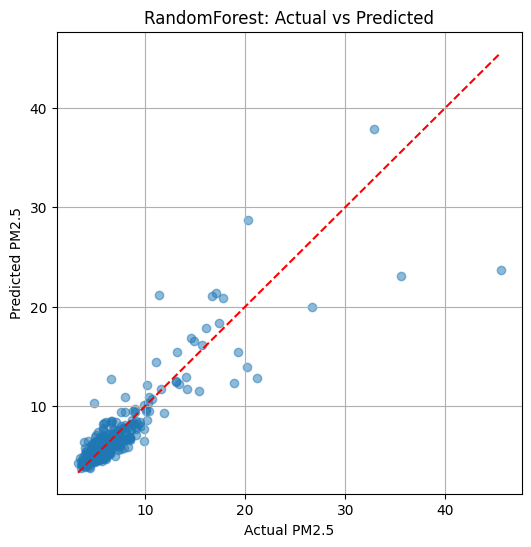

In [10]:
# -------------------------------------------------------------
# Train a Random Forest model and visualize predictions
# -------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model with defined hyperparameters
rf = RandomForestRegressor(
    n_estimators=300,   # number of trees in the forest
    max_depth=None,     # allow trees to grow fully
    random_state=42     # ensures reproducible results
)

# Train the model on the training portion of the dataset
rf.fit(X_train, y_train)

# Generate predictions on the test dataset
y_pred_rf = rf.predict(X_test)

# -------------------------------------------------------------
# Plot: Actual vs Predicted PM2.5 (Random Forest)
# -------------------------------------------------------------
plt.figure(figsize=(6,6))

# Scatter plot comparing true values vs predicted values
plt.scatter(y_test, y_pred_rf, alpha=0.5)

# Axis labels and title
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("RandomForest: Actual vs Predicted")

# Add a dashed 45-degree reference line (perfect predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

# Display grid and the final figure
plt.grid(True)
plt.show()


In [11]:
# -------------------------------------------------------------
# Evaluate the Random Forest model on the test dataset
# -------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance (Test Set)")
print("-------------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


Random Forest Performance (Test Set)
-------------------------------------
MAE : 1.1526237645744648
RMSE: 2.2359344563543555
R²  : 0.7627080576893371


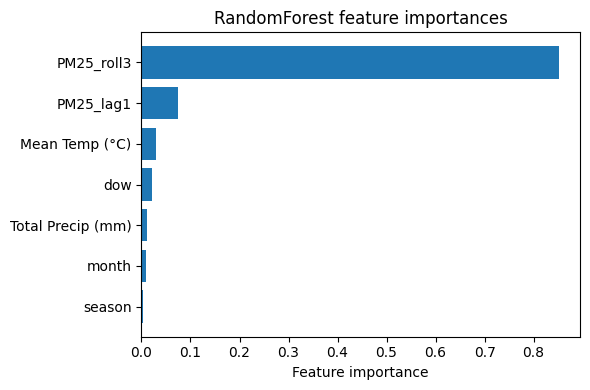

In [12]:
# -------------------------------------------------------------
# Plot feature importances from the trained Random Forest model
# -------------------------------------------------------------

# Extract the feature importance values from the Random Forest
importances = rf.feature_importances_

# Sort feature indices by importance (ascending order)
sorted_idx = np.argsort(importances)

# Create a horizontal bar chart of feature importance values
plt.figure(figsize=(6, 4))
plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])

# Label the axes and add a title
plt.xlabel("Feature importance")
plt.title("RandomForest feature importances")

# Adjust layout for better readability
plt.tight_layout()

# Display the plot
plt.show()


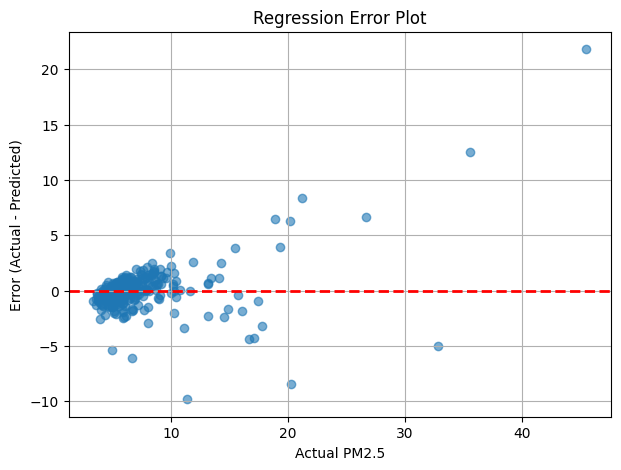

In [13]:
# -------------------------------------------------------------
# Regression Error Plot: Visualize prediction errors
# -------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Calculate prediction errors (actual minus predicted values)
errors = y_test - y_pred_rf

# Create a scatter plot of actual PM2.5 vs. error
plt.figure(figsize=(7,5))
plt.scatter(y_test, errors, alpha=0.6)

# Add a horizontal reference line at zero error
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Label axes and add plot title
plt.xlabel("Actual PM2.5")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Regression Error Plot")

# Display grid and show the plot
plt.grid(True)
plt.show()


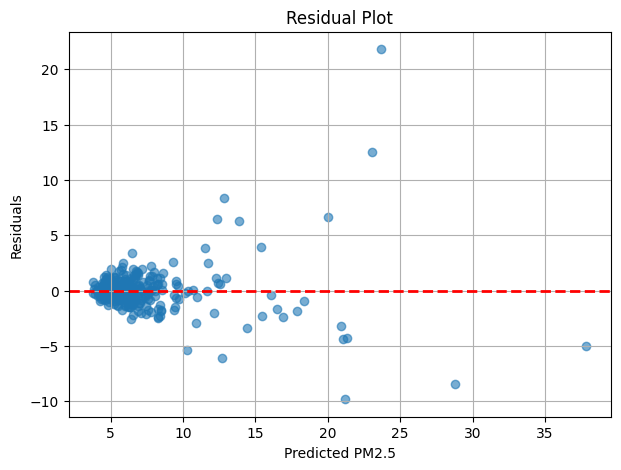

In [14]:
# -------------------------------------------------------------
# Residual Plot: Visualize residuals vs. predicted values
# -------------------------------------------------------------

# Calculate residuals (difference between actual and predicted PM2.5)
residuals = y_test - y_pred_rf

# Create a scatter plot of predicted PM2.5 vs. residuals
plt.figure(figsize=(7,5))
plt.scatter(y_pred_rf, residuals, alpha=0.6)

# Add a horizontal reference line at zero residual
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Label axes and add plot title
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Display grid and show the plot
plt.grid(True)
plt.show()
